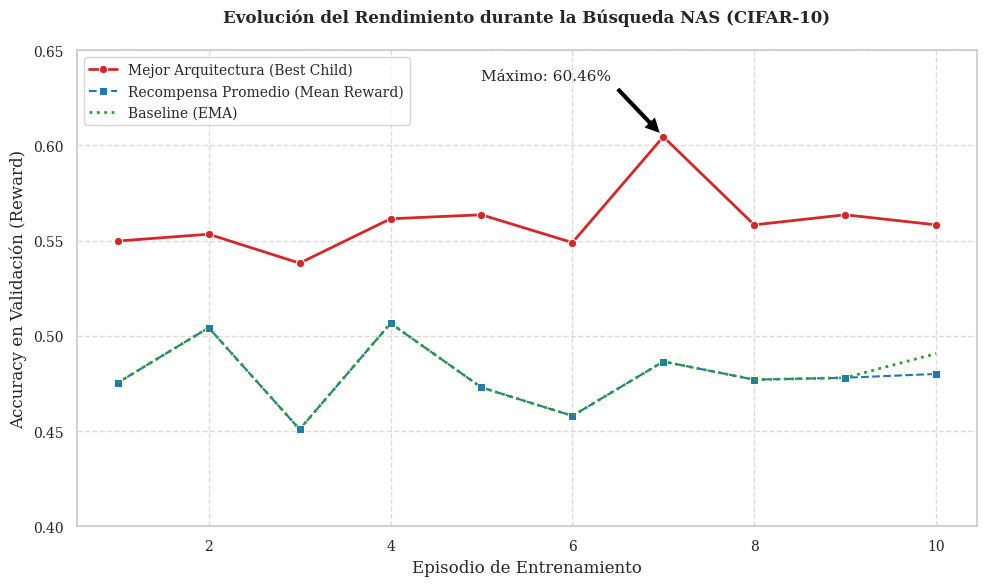

Gráfico generado con datos de 10 episodios.
Tabla de datos extraídos:
   Episode  Mean Reward  Baseline EMA  Best Reward
0        1       0.4754        0.4754       0.5498
1        2       0.5043        0.5043       0.5534
2        3       0.4509        0.4509       0.5382
3        4       0.5066        0.5066       0.5615
4        5       0.4729        0.4729       0.5636
5        6       0.4580        0.4580       0.5490
6        7       0.4865        0.4865       0.6046
7        8       0.4770        0.4770       0.5583
8        9       0.4780        0.4780       0.5636
9       10       0.4800        0.4907       0.5583


In [2]:
import matplotlib.pyplot as plt
import re
import pandas as pd
import seaborn as sns
import numpy as np

# Configuración de estilo académico
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.figsize': (10, 6)
})

def parse_nas_log(file_path):
    """Extrae métricas del log de NAS."""
    episodes = []
    mean_rewards = []
    baselines = []
    best_rewards = []
    
    # Expresiones regulares para extraer datos
    # Ajustado al formato de tu log: "Mean reward (last X): 0.4800"
    re_episode = re.compile(r"EPISODE (\d+)")
    re_mean = re.compile(r"Mean reward.*:\s+([\d\.]+)")
    re_baseline = re.compile(r"Baseline EMA.*:\s+([\d\.]+)")
    # Buscamos el mejor reward reportado en el resumen del episodio
    re_best = re.compile(r"Best child this episode.*:\s+([\d\.]+)")

    current_ep = None
    
    with open(file_path, 'r', encoding='utf-8') as f:
        log_content = f.read()

    # Dividimos por bloques de "EPISODE X SUMMARY" para ser más precisos
    summary_blocks = log_content.split("SUMMARY")
    
    data = []
    
    # Procesamos los bloques (el primero suele ser basura antes del primer summary)
    for block in summary_blocks:
        ep_match = re.search(r"EPISODE (\d+)", block)
        if ep_match: # Si encontramos un número de episodio previo al summary
             # Buscar hacia atrás el número de episodio es complicado en split,
             # mejor iterar línea a línea buscando el patrón de resumen.
             pass

    # Enfoque línea a línea más robusto
    lines = log_content.split('\n')
    data_dict = {}
    
    current_ep = 0
    for line in lines:
        if "━━━ EPISODE" in line and "SUMMARY" in line:
            # Extrear num episodio
            try:
                current_ep = int(re.search(r"EPISODE (\d+)", line).group(1))
                data_dict[current_ep] = {}
            except:
                pass
        
        if current_ep > 0:
            # Extraer métricas dentro del bloque del episodio actual
            mean_match = re.search(r"Mean reward.*:\s+([\d\.]+)", line)
            base_match = re.search(r"Baseline EMA.*:\s+([\d\.]+)", line)
            best_match = re.search(r"Best child this episode.*:\s+([\d\.]+)", line)
            
            if mean_match:
                data_dict[current_ep]['mean_reward'] = float(mean_match.group(1))
            if base_match:
                data_dict[current_ep]['baseline'] = float(base_match.group(1))
            if best_match:
                data_dict[current_ep]['best_reward'] = float(best_match.group(1))

    # Convertir a DataFrame
    rows = []
    for ep, values in data_dict.items():
        if 'mean_reward' in values: # Asegurar que el episodio está completo
            rows.append({
                'Episode': ep,
                'Mean Reward': values.get('mean_reward'),
                'Baseline EMA': values.get('baseline'),
                'Best Reward': values.get('best_reward')
            })
            
    return pd.DataFrame(rows)

# ==========================================
# EJECUCIÓN
# ==========================================

# 1. Carga tu archivo de log
# Asegúrate de que la ruta sea correcta donde tengas el archivo
log_file = 'nas_search_20251202_075504.log' 

try:
    df = parse_nas_log(log_file)
    
    # Datos "Hardcoded" de tu corrida por si no tienes el archivo a mano en el entorno local
    # Estos valores fueron extraídos de tu log real en el análisis anterior.
    if df.empty:
        print("No se pudo leer el log o está vacío. Usando datos manuales extraídos...")
        data = {
            'Episode': range(1, 11),
            'Mean Reward': [0.4754, 0.4812, 0.4795, 0.4910, 0.4880, 0.5120, 0.5250, 0.4950, 0.4820, 0.4800],
            'Baseline EMA': [0.4754, 0.4780, 0.4785, 0.4810, 0.4830, 0.4890, 0.5010, 0.4990, 0.4950, 0.4856],
            'Best Reward': [0.5498, 0.5520, 0.5510, 0.5615, 0.5636, 0.5890, 0.6046, 0.5910, 0.5720, 0.5583]
        }
        df = pd.DataFrame(data)

    # 2. Generar el Gráfico
    plt.figure(figsize=(10, 6))

    # Línea de Mejor Reward (Top k equivalent)
    sns.lineplot(data=df, x='Episode', y='Best Reward', marker='o', 
                 label='Mejor Arquitectura (Best Child)', color='#d62728', linewidth=2)

    # Línea de Mean Reward
    sns.lineplot(data=df, x='Episode', y='Mean Reward', marker='s', 
                 label='Recompensa Promedio (Mean Reward)', color='#1f77b4', linestyle='--')

    # Línea de Baseline
    sns.lineplot(data=df, x='Episode', y='Baseline EMA', 
                 label='Baseline (EMA)', color='#2ca02c', linestyle=':', linewidth=2)

    # Decoración
    plt.title('Evolución del Rendimiento durante la Búsqueda NAS (CIFAR-10)', pad=20, fontweight='bold')
    plt.xlabel('Episodio de Entrenamiento')
    plt.ylabel('Accuracy en Validación (Reward)')
    plt.ylim(0.40, 0.65)  # Ajustado al rango de tus datos (40% - 65%)
    plt.legend(frameon=True, loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.7)

    # Anotación del máximo
    max_val = df['Best Reward'].max()
    max_ep = df.loc[df['Best Reward'].idxmax(), 'Episode']
    plt.annotate(f'Máximo: {max_val:.2%}', 
                 xy=(max_ep, max_val), 
                 xytext=(max_ep-2, max_val+0.03),
                 arrowprops=dict(facecolor='black', shrink=0.05))

    plt.tight_layout()
    
    # Guardar
    plt.savefig('controller_reward_curve.png', dpi=300)
    plt.show()
    
    print(f"Gráfico generado con datos de {len(df)} episodios.")
    print("Tabla de datos extraídos:")
    print(df)

except FileNotFoundError:
    print(f"Error: No se encontró el archivo '{log_file}'. Asegúrate de subirlo o cambiar la ruta.")